# Sample Grouping


We use the handwritten digits dataset and attempt to classify them.

In [1]:
from sklearn.datasets import load_digits

digits = load_digits()
data, target = digits.data, digits.target

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(max_iter=1000)
)

We now compare cross-validation strategies, starting with `KFold` with and without shuffling.

In [4]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(shuffle=False)
test_score_no_shuffling = cross_val_score(model, data, target, cv=cv, n_jobs=2)
print(
    "The average accuracy is "
    f"{test_score_no_shuffling.mean():.3f} ± "
    f"{test_score_no_shuffling.std():.3f}"
)

The average accuracy is 0.931 ± 0.027


In [5]:
cv = KFold(shuffle=True)
test_score_with_shuffling = cross_val_score(
    model, data, target, cv=cv, n_jobs=2
)
print(
    "The average accuracy is "
    f"{test_score_with_shuffling.mean():.3f} ± "
    f"{test_score_with_shuffling.std():.3f}"
)

The average accuracy is 0.969 ± 0.008


In [6]:
import pandas as pd

all_scores = pd.DataFrame(
    [test_score_no_shuffling, test_score_with_shuffling],
    index=["KFold without shuffling", "KFold with shuffling"],
).T

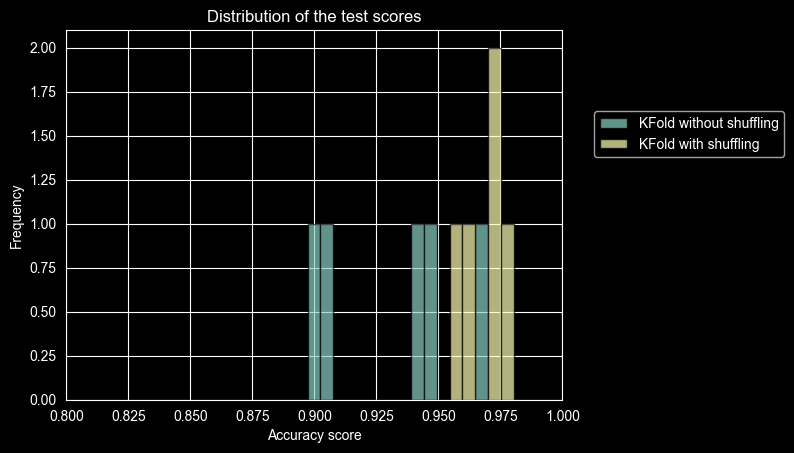

In [7]:
import matplotlib.pyplot as plt

all_scores.plot.hist(bins=16, edgecolor="black", alpha=0.7)
plt.xlim([0.8, 1.0])
plt.xlabel("Accuracy score")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Distribution of the test scores")

What we know from checking the description of the data set is that 13 writers wrote the digits by hand. If we grouped the data by these writers, we can expect a lower generalization score as the model would simply be memorizing each writer's patterns rather than learning how to identify digits.